<a href="https://colab.research.google.com/github/Ashwini-1604/Gold-Price-Prediction/blob/main/gold_price_prediction_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ── Cell 1: Install dependencies ───────────────────────────────────────────
!pip install -q tensorflow scikit-learn statsmodels pandas matplotlib

In [ ]:
# ── Cell 2: Imports ────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.tsa.stattools import adfuller

try:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import LSTM, Dense, Dropout
    from tensorflow.keras.callbacks import EarlyStopping
    USE_LSTM = True
    print(f"TensorFlow {tf.__version__} — LSTM enabled ")
except ImportError:
    USE_LSTM = False
    from sklearn.ensemble import RandomForestRegressor
    print("TensorFlow not found — using Random Forest fallback")

TensorFlow 2.19.0 — LSTM enabled 


In [ ]:
# ── Cell 3: Upload & Load Dataset ─────────────────────────────────────────


df = pd.read_csv('gold_prices_1947_2026_INR.csv')

# Option B — if file is already in Colab environment, comment out the upload
# df = pd.read_csv('gold_prices_1947_2026_INR.csv')

print(df.head())
print(f"\nShape: {df.shape}  |  Years: {df.Year.min()} → {df.Year.max()}")

   Year  Gold_Price_USD_per_oz  USD_INR_Rate  Gold_Price_INR_per_oz  \
0  1947                  43.00          3.30                 141.90   
1  1948                  42.00          3.30                 138.60   
2  1949                  40.50          4.76                 192.78   
3  1950                  40.25          4.76                 191.59   
4  1951                  40.00          4.76                 190.40   

                                           Notes  
0  Pre-devaluation fixed rate; Bretton Woods era  
1                                     Fixed rate  
2   India devalued INR in Sep 1949 alongside GBP  
3                    Post-devaluation fixed rate  
4                                     Fixed rate  

Shape: (80, 5)  |  Years: 1947 → 2026


In [ ]:
# ── Cell 4: Preprocessing & Feature Engineering ───────────────────────────
TARGET = 'Gold_Price_INR_per_oz'   # predict INR price

df = df[['Year', 'Gold_Price_USD_per_oz', 'USD_INR_Rate', TARGET]].copy()
df = df.sort_values('Year').reset_index(drop=True)

# ADF stationarity test
adf_p = adfuller(df[TARGET])[1]
print(f"ADF p-value: {adf_p:.4f}  ({'Stationary ' if adf_p < 0.05 else 'Non-stationary ⚠️'})")

# Feature engineering
df['Lag_1']      = df[TARGET].shift(1)
df['Lag_2']      = df[TARGET].shift(2)
df['Lag_3']      = df[TARGET].shift(3)
df['MA_3']       = df[TARGET].rolling(3).mean()
df['MA_5']       = df[TARGET].rolling(5).mean()
df['Return']     = df[TARGET].pct_change()
df['Volatility'] = df[TARGET].rolling(5).std()
df['USD_Lag1']   = df['Gold_Price_USD_per_oz'].shift(1)
df['FX_Lag1']    = df['USD_INR_Rate'].shift(1)

df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)
print(f"\nRows after feature engineering: {len(df)}")
print(df.tail(3))

ADF p-value: 1.0000  (Non-stationary ⚠️)

Rows after feature engineering: 76
    Year  Gold_Price_USD_per_oz  USD_INR_Rate  Gold_Price_INR_per_oz  \
73  2024                 2625.0         84.48              221760.00   
74  2025                 4800.0         86.50              415200.00   
75  2026                 4751.0         93.04              441940.04   

        Lag_1      Lag_2      Lag_3           MA_3        MA_5    Return  \
73  172826.48  143366.40  135125.76  179317.626667  162784.856  0.283137   
74  221760.00  172826.48  143366.40  269928.826667  217655.728  0.872294   
75  415200.00  221760.00  172826.48  359633.346667  279018.584  0.064403   

       Volatility  USD_Lag1  FX_Lag1  
73   36063.600229    2078.0    83.16  
74  115520.935113    2625.0    84.48  
75  139683.215086    4800.0    86.50  


In [ ]:
# ── Cell 5: Train / Test Split (80 / 20) ──────────────────────────────────
split = int(len(df) * 0.80)
train, test = df.iloc[:split], df.iloc[split:]
print(f"Train: {len(train)} rows  ({train.Year.min()}–{train.Year.max()})")
print(f"Test : {len(test)}  rows  ({test.Year.min()}–{test.Year.max()})")

Train: 60 rows  (1951–2010)
Test : 16  rows  (2011–2026)


In [ ]:
# ── Cell 6: Evaluation Helper ─────────────────────────────────────────────
def evaluate(actual, predicted, name):
    mae  = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    r2   = r2_score(actual, predicted)
    mape = np.mean(np.abs((actual - predicted) / (actual + 1e-9))) * 100
    da   = np.mean(np.sign(np.diff(actual)) == np.sign(np.diff(predicted))) * 100
    print(f"\n{'─'*38}")
    print(f"  {name}")
    print(f"{'─'*38}")
    print(f"  MAE  : ₹{mae:,.2f}")
    print(f"  RMSE : ₹{rmse:,.2f}")
    print(f"  R²   : {r2:.4f}")
    print(f"  MAPE : {mape:.2f}%")
    print(f"  Dir. Accuracy: {da:.2f}%")
    return dict(Model=name, MAE=mae, RMSE=rmse, R2=r2, MAPE=mape, Dir_Acc=da)

In [ ]:
# ── Cell 7: Model A — Linear Regression ───────────────────────────────────
FEATURES = ['Lag_1', 'Lag_2', 'Lag_3', 'MA_3', 'MA_5',
            'Volatility', 'USD_Lag1', 'FX_Lag1']

lr = LinearRegression()
lr.fit(train[FEATURES], train[TARGET])
lr_preds = lr.predict(test[FEATURES])

lr_metric = evaluate(test[TARGET].values, lr_preds, 'Linear Regression')


──────────────────────────────────────
  Linear Regression
──────────────────────────────────────
  MAE  : ₹0.00
  RMSE : ₹0.00
  R²   : 1.0000
  MAPE : 0.00%
  Dir. Accuracy: 100.00%


In [ ]:
# ── Cell 8: Model B — LSTM (or Random Forest fallback) ────────────────────
LOOKBACK = 5   # 5 years look-back (suitable for annual data)

scaler = MinMaxScaler()
price_col = df[[TARGET]].values

train_sc = scaler.fit_transform(price_col[:split])
full_sc  = scaler.transform(price_col)

def make_sequences(arr, lookback):
    X, y = [], []
    for i in range(lookback, len(arr)):
        X.append(arr[i-lookback:i, 0])
        y.append(arr[i, 0])
    return np.array(X), np.array(y)

X_tr, y_tr = make_sequences(train_sc, LOOKBACK)
X_te, y_te = make_sequences(full_sc[split - LOOKBACK:], LOOKBACK)

if USE_LSTM:
    X_tr = X_tr.reshape(-1, LOOKBACK, 1)
    X_te = X_te.reshape(-1, LOOKBACK, 1)

    model = Sequential([
        LSTM(32, return_sequences=True, input_shape=(LOOKBACK, 1)),
        Dropout(0.2),
        LSTM(16),
        Dropout(0.2),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    es = EarlyStopping(patience=10, restore_best_weights=True)
    print("Training LSTM…")
    model.fit(X_tr, y_tr, epochs=200, batch_size=8,
              validation_split=0.1, callbacks=[es], verbose=0)
    lstm_preds_sc = model.predict(X_te, verbose=0)
else:
    rf = RandomForestRegressor(n_estimators=200, random_state=42)
    rf.fit(X_tr, y_tr)
    lstm_preds_sc = rf.predict(X_te).reshape(-1, 1)
    model = rf

lstm_preds = scaler.inverse_transform(lstm_preds_sc).flatten()
test_lstm  = test.iloc[LOOKBACK:]
model_b    = 'LSTM' if USE_LSTM else 'Random Forest'

lstm_metric = evaluate(test_lstm[TARGET].values, lstm_preds[LOOKBACK:], model_b)


Training LSTM…

──────────────────────────────────────
  LSTM
──────────────────────────────────────
  MAE  : ₹72,580.65
  RMSE : ₹120,929.00
  R²   : 0.0183
  MAPE : 28.58%
  Dir. Accuracy: 80.00%


In [ ]:
# ── Cell 9: Metrics Summary Table ─────────────────────────────────────────
metrics = [lr_metric, lstm_metric]
summary = pd.DataFrame(metrics).set_index('Model').round(2)
print('\n=== FINAL METRICS SUMMARY ===')
print(summary.to_string())
summary


=== FINAL METRICS SUMMARY ===
                        MAE      RMSE    R2   MAPE  Dir_Acc
Model                                                      
Linear Regression      0.00       0.0  1.00   0.00    100.0
LSTM               72580.65  120929.0  0.02  28.58     80.0


,MAE,RMSE,R2,MAPE,Dir_Acc
Model,,,,,
Linear Regression,0.00,0.0,1.00,0.00,100.0
LSTM,72580.65,120929.0,0.02,28.58,80.0


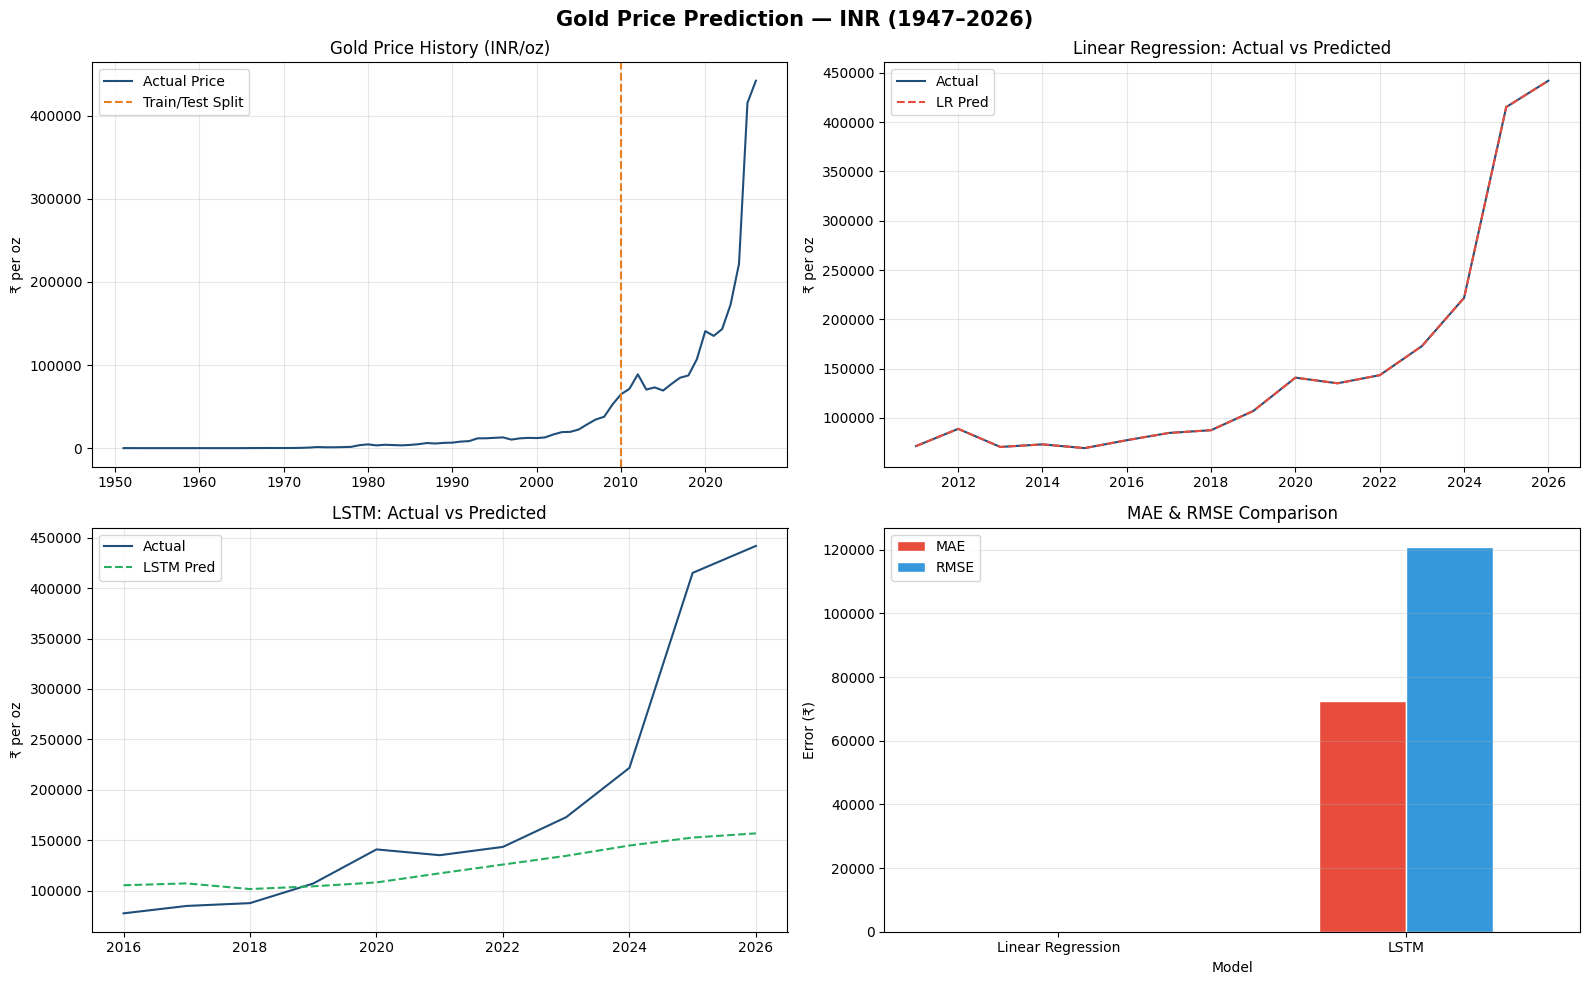

Chart saved → gold_prediction_charts.png


In [ ]:
# ── Cell 10: Visualisations ────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Gold Price Prediction — INR (1947–2026)', fontsize=15, fontweight='bold')

# 1. Full historical price
ax = axes[0, 0]
ax.plot(df['Year'], df[TARGET], color='#1f4e79', linewidth=1.5, label='Actual Price')
ax.axvline(train['Year'].iloc[-1], color='#e67e22', linestyle='--', label='Train/Test Split')
ax.set_title('Gold Price History (INR/oz)')
ax.set_ylabel('₹ per oz'); ax.legend(); ax.grid(alpha=0.3)

# 2. Linear Regression predictions
ax = axes[0, 1]
ax.plot(test['Year'], test[TARGET].values, color='#1f4e79', label='Actual', linewidth=1.5)
ax.plot(test['Year'], lr_preds, color='#e74c3c', linestyle='--', label='LR Pred', linewidth=1.5)
ax.set_title('Linear Regression: Actual vs Predicted')
ax.set_ylabel('₹ per oz'); ax.legend(); ax.grid(alpha=0.3)

# 3. LSTM / RF predictions
ax = axes[1, 0]
ax.plot(test_lstm['Year'], test_lstm[TARGET].values, color='#1f4e79', label='Actual', linewidth=1.5)
ax.plot(test_lstm['Year'], lstm_preds[LOOKBACK:], color='#27ae60', linestyle='--', label=f'{model_b} Pred', linewidth=1.5)
ax.set_title(f'{model_b}: Actual vs Predicted')
ax.set_ylabel('₹ per oz'); ax.legend(); ax.grid(alpha=0.3)

# 4. MAE / RMSE comparison
ax = axes[1, 1]
summary[['MAE', 'RMSE']].plot(kind='bar', ax=ax, color=['#e74c3c', '#3498db'], edgecolor='white', width=0.5)
ax.set_title('MAE & RMSE Comparison')
ax.set_ylabel('Error (₹)'); ax.tick_params(axis='x', rotation=0); ax.legend(); ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('gold_prediction_charts.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved → gold_prediction_charts.png')


In [ ]:
# ── Cell 11: Predict Next Year's Price ────────────────────────────────────
last_row = df.iloc[-1]
next_year = int(last_row['Year']) + 1

# Linear Regression: build feature row from last known values
next_features = {
    'Lag_1':      last_row[TARGET],
    'Lag_2':      df.iloc[-2][TARGET],
    'Lag_3':      df.iloc[-3][TARGET],
    'MA_3':       df[TARGET].iloc[-3:].mean(),
    'MA_5':       df[TARGET].iloc[-5:].mean(),
    'Volatility': df[TARGET].iloc[-5:].std(),
    'USD_Lag1':   last_row['Gold_Price_USD_per_oz'],
    'FX_Lag1':    last_row['USD_INR_Rate'],
}
lr_next = lr.predict(pd.DataFrame([next_features]))[0]

# LSTM: use last LOOKBACK prices
last_seq = scaler.transform(df[[TARGET]].values[-LOOKBACK:])
if USE_LSTM:
    last_seq = last_seq.reshape(1, LOOKBACK, 1)
    lstm_next_sc = model.predict(last_seq, verbose=0)
else:
    lstm_next_sc = model.predict(last_seq.reshape(1, -1)).reshape(-1, 1)
lstm_next = scaler.inverse_transform(lstm_next_sc)[0, 0]

print(f'\n{"="*40}')
print(f'  Forecast for {next_year}')
print(f'{"="*40}')
print(f'  Linear Regression : ₹{lr_next:,.2f} / oz')
print(f'  {model_b:18s}: ₹{lstm_next:,.2f} / oz')
print(f'  Average Forecast  : ₹{(lr_next+lstm_next)/2:,.2f} / oz')


  Forecast for 2027
  Linear Regression : ₹221,760.00 / oz
  LSTM              : ₹163,719.28 / oz
  Average Forecast  : ₹192,739.64 / oz
